# SDカード消費電流解析

nrf_sd_power_test.ino で取得した電流データを解析する。

**測定パターン**:
- パターン1: 1秒分 (664 bytes) 書き込み × 10回
- パターン2: 60秒分 (39840 bytes) 一括書き込み × 10回

**サイクル**: SD電源ON → 2秒待ち → 書き込み → 電源OFF → 5秒インターバル

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 設定
# ============================================================
CSV_FILE = 'dist/current_log.csv'

# 測定時間範囲
START_TIME = '2026-03-17 17:52:09'
END_TIME = '2026-03-17 17:54:40'

# SD書き込み検出の閾値 (mA)
# SD書き込みスパイクは~35-57mA, 電源ONのみは~5mA
ON_THRESHOLD_MA = 10.0

# 測定パターン
REPS = 10
PATTERN_NAMES = ['1秒分 (664 bytes)', '60秒分 (39840 bytes)']
NUM_PATTERNS = len(PATTERN_NAMES)

In [67]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

if START_TIME:
    df = df[df['Timestamp'] >= pd.to_datetime(START_TIME)]
if END_TIME:
    df = df[df['Timestamp'] <= pd.to_datetime(END_TIME)]

df = df.reset_index(drop=True)
df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'サンプリング間隔: {df["elapsed_s"].diff().median()*1000:.1f} ms')

データ件数: 2950
時間範囲: 2026-03-17 17:52:09.017179 ~ 2026-03-17 17:54:39.961783
サンプリング間隔: 50.8 ms


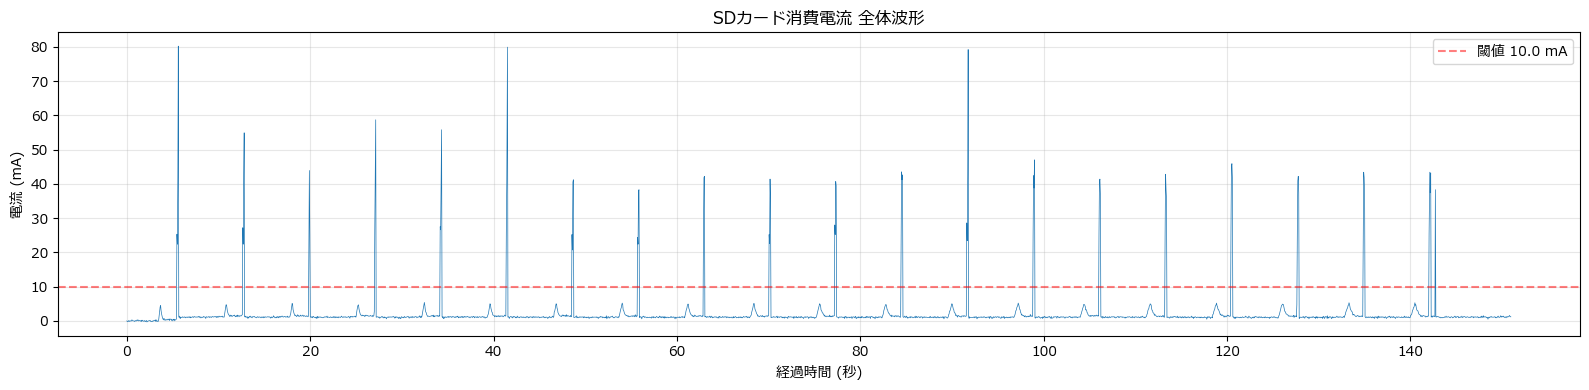

In [68]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['elapsed_s'], df['Current (mA)'], linewidth=0.5)
ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('SDカード消費電流 全体波形')
ax.axhline(y=ON_THRESHOLD_MA, color='r', linestyle='--', alpha=0.5, label=f'閾値 {ON_THRESHOLD_MA} mA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# SD書き込み区間の自動検出
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

is_on = current > ON_THRESHOLD_MA
transitions = np.diff(is_on.astype(int))
on_starts = np.where(transitions == 1)[0] + 1
on_ends = np.where(transitions == -1)[0] + 1

if is_on[0]:
    on_starts = np.insert(on_starts, 0, 0)
if is_on[-1]:
    on_ends = np.append(on_ends, len(is_on))

n_cycles = min(len(on_starts), len(on_ends))
on_starts = on_starts[:n_cycles]
on_ends = on_ends[:n_cycles]

# SD書き込みスパイクは150-200ms程度。100ms未満のノイズのみ除外
valid = []
for s, e in zip(on_starts, on_ends):
    duration = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if duration >= 0.10:
        valid.append((s, e))

print(f'検出された書き込み区間: {len(valid)} 回')
print(f'期待値: {NUM_PATTERNS * REPS} 回')

if len(valid) > 0:
    durations = [timestamps[min(e, len(timestamps)-1)] - timestamps[s] for s, e in valid]
    print(f'書き込み時間: 平均 {np.mean(durations)*1000:.0f} ms, 最大 {np.max(durations)*1000:.0f} ms')

検出された書き込み区間: 20 回
期待値: 20 回
書き込み時間: 平均 195 ms, 最大 227 ms


In [72]:
# ============================================================
# 各ON区間の統計
# ============================================================
results = []
total_expected = NUM_PATTERNS * REPS

for i, (s, e) in enumerate(valid):
    segment = df.iloc[s:e]
    duration_s = segment['elapsed_s'].iloc[-1] - segment['elapsed_s'].iloc[0]
    mean_ma = segment['Current (mA)'].mean()
    peak_ma = segment['Current (mA)'].max()

    if i < total_expected:
        pattern_idx = i // REPS
        rep_idx = i % REPS
        pattern_name = PATTERN_NAMES[pattern_idx] if pattern_idx < NUM_PATTERNS else '不明'
    else:
        pattern_name = '不明'
        rep_idx = i

    results.append({
        'cycle': i + 1,
        'pattern': pattern_name,
        'rep': rep_idx + 1,
        'duration_s': duration_s,
        'mean_mA': mean_ma,
        'peak_mA': peak_ma,
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 cycle            pattern  rep  duration_s   mean_mA  peak_mA
     1    1秒分 (664 bytes)    1    0.151613 42.550000     80.2
     2    1秒分 (664 bytes)    2    0.152918 36.875000     54.9
     3    1秒分 (664 bytes)    3    0.101467 31.100000     43.9
     4    1秒分 (664 bytes)    4    0.101879 42.733333     58.7
     5    1秒分 (664 bytes)    5    0.153104 37.775000     55.8
     6    1秒分 (664 bytes)    6    0.126989 48.666667     79.9
     7    1秒分 (664 bytes)    7    0.152390 31.900000     41.2
     8    1秒分 (664 bytes)    8    0.151456 30.750000     38.3
     9    1秒分 (664 bytes)    9    0.102607 36.833333     42.2
    10    1秒分 (664 bytes)   10    0.152512 31.025000     41.4
    11 60秒分 (39840 bytes)    1    0.153192 33.350000     40.7
    12 60秒分 (39840 bytes)    2    0.152341 38.100000     43.5
    13 60秒分 (39840 bytes)    3    0.151597 43.475000     79.2
    14 60秒分 (39840 bytes)    4    0.151767 38.325000     47.0
    15 60秒分 (39840 bytes)    5    0.152645 36.025000     41.4
    16 6

In [73]:
# ============================================================
# パターンごとの集計
# ============================================================
summary = df_results.groupby('pattern').agg(
    回数=('mean_mA', 'count'),
    ON区間_平均秒=('duration_s', 'mean'),
    平均電流_mA=('mean_mA', 'mean'),
    電流標準偏差_mA=('mean_mA', 'std'),
    ピーク電流_mA=('peak_mA', 'max'),
).reset_index()
summary.columns = ['パターン', '回数', 'ON区間平均(秒)', '平均電流(mA)', '標準偏差(mA)', 'ピーク電流(mA)']

print('\n=== パターンごとの集計 ===')
print(summary.to_string(index=False))

# ベースライン電流 (ON区間外)
all_on_indices = set()
for s, e in valid:
    all_on_indices.update(range(s, e))
off_mask = ~df.index.isin(all_on_indices)
baseline = df.loc[off_mask, 'Current (mA)'].mean()
print(f'\nベースライン電流 (SD OFF): {baseline:.2f} mA')


=== パターンごとの集計 ===
              パターン  回数  ON区間平均(秒)  平均電流(mA)  標準偏差(mA)  ピーク電流(mA)
   1秒分 (664 bytes)  10   0.134694 37.020833  6.110169       80.2
60秒分 (39840 bytes)  10   0.154672 37.512500  2.731230       79.2

ベースライン電流 (SD OFF): 1.33 mA


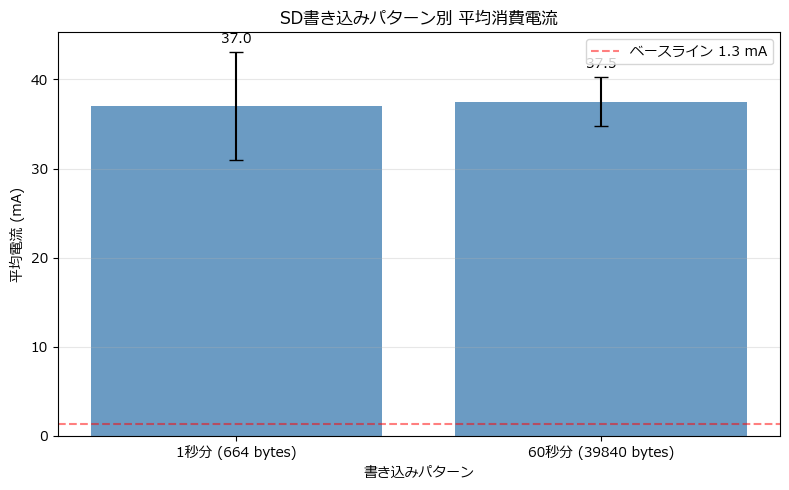

In [74]:
# ============================================================
# パターンごとの平均電流グラフ
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

x = summary['パターン'].values
y = summary['平均電流(mA)'].values
yerr = summary['標準偏差(mA)'].values

ax.bar(range(len(x)), y, yerr=yerr, capsize=5, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_xlabel('書き込みパターン')
ax.set_ylabel('平均電流 (mA)')
ax.set_title('SD書き込みパターン別 平均消費電流')
ax.axhline(y=baseline, color='r', linestyle='--', alpha=0.5, label=f'ベースライン {baseline:.1f} mA')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (v, e) in enumerate(zip(y, yerr)):
    ax.text(i, v + e + 1, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

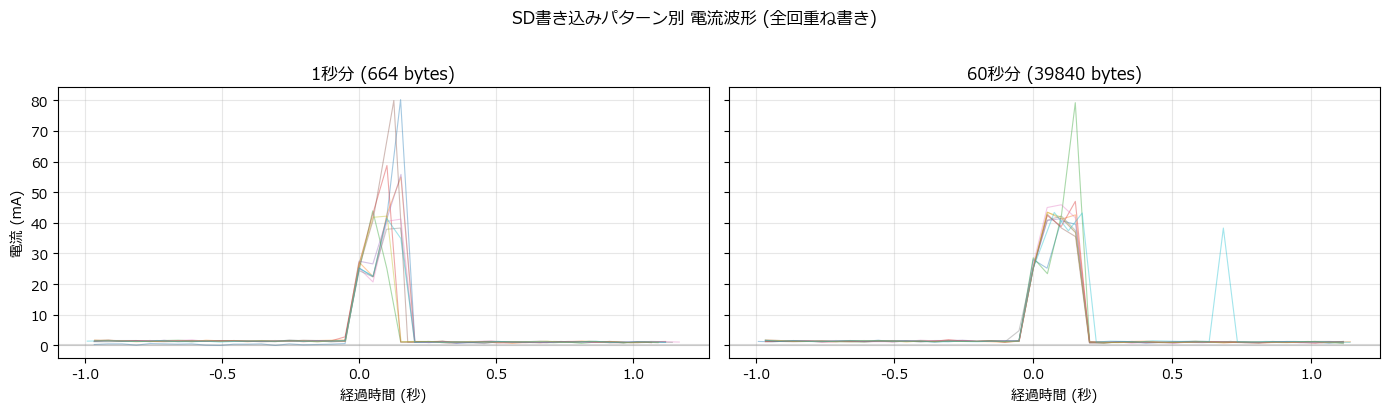

In [75]:
# ============================================================
# 各パターンの代表的な電流波形 (重ね書き)
# ============================================================
fig, axes = plt.subplots(1, NUM_PATTERNS, figsize=(14, 4), sharey=True)

for pidx in range(NUM_PATTERNS):
    ax = axes[pidx]
    start_rep = pidx * REPS
    end_rep = start_rep + REPS

    for i in range(start_rep, min(end_rep, len(valid))):
        s, e = valid[i]
        # ON区間の前後1秒を含めて表示
        margin = int(1.0 / (df['elapsed_s'].diff().median()))  # ~1秒分のサンプル数
        s_ext = max(0, s - margin)
        e_ext = min(len(df), e + margin)
        segment = df.iloc[s_ext:e_ext]
        t = segment['elapsed_s'].values - df.iloc[s]['elapsed_s']
        ax.plot(t, segment['Current (mA)'].values, alpha=0.4, linewidth=0.8)

    ax.set_title(PATTERN_NAMES[pidx])
    ax.set_xlabel('経過時間 (秒)')
    if pidx == 0:
        ax.set_ylabel('電流 (mA)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

fig.suptitle('SD書き込みパターン別 電流波形 (全回重ね書き)', y=1.02)
plt.tight_layout()
plt.show()